# Lab 5 Presentation - Cross Validation for non-i.i.d data

Lucas Schwengber

Today’s goals (see the [exercise](lab5_exercise_2026.qmd)):

1.  Understanding what happens with model performance estimates when
    data is non-i.i.d..
2.  Providing reasonable estimators of performance in such cases.
3.  Performing hyperparameter selection and inference on such setting.

*This presentation is adapted from Erez Buchweitz’s cross validation
lab.*

LLM assistance was used during the elaboration of this presentation and
the exercise.

# Estimating the hold-out risk for non i.i.d. data

The discussions on last week’s
[lab](../lab4_cross_val/lab4_presentation_2026.ipynb) hinged on a key
assumption: that both training and test data were i.i.d. drawn from the
same population. This assumption often fails in practice. The simplest
failure modes are for example for data involving spatial or temporal
components, both of which we will visit in today’s lab.

In a setting like this we imagine we have
$\mathcal{T} = (\boldsymbol{X}_T, \boldsymbol{y}_T)$ drawn from a
distribution $P$ over training sets, but our model will be deployed and
should perform on data $(\boldsymbol{x}, y)$ which is either drawn from
some distinct distribution $Q$, and/or for which we cannot assume
independence from $\mathcal{T}$.

As a simple example (to be worked below) imagine trying to predict
eletric energy consumption in different regions of the United States.
Suppose we are given as training data from regions R_1,…,R_5, but our
model will be deployed to predict consumption on some distinct region
R_6. It could be that region R_6 differs from R_1,…,R_5 in ways which
strongly violate i.i.d. assumptions. For example, if R_6 consists of
only Alaska, whereas R_1,…,R_5 consists of the 5 most populous states,
it seems fairly unreasonable to assumption the “identically
distribution” assumption makes sense.

In cases like these, doing the standard CV estimation based on uniformly
shuffling the data and splitting it into folds may fail to provide
accurate out of training performance estimates. The reason for this is
that:

> the *relation between* the training and validation distributions
> within each split, *does not* faithfully mirror the *relation between*
> the full training data and the data the model will deployed on.

The fix for this is trying to make the split in such a way that this
“mirroring” holds as faithfully as possible.

Another way of thinking about this informally, is that, letting $H$ be
data where the model will be deployed, and letting $\mathcal{T}^{(-k)}$
and $\mathcal{T}^{(k)}$ be a K-fold CV split of $\mathcal{T}$. We want
that the information which a model can reasonably extract from
$\mathcal{T}$ about $H$ is as close as possible to the one that it can
exact from $\mathcal{T}^{(k)}$ about $\mathcal{T}$. This in particular
implies that:

$$\E_{(x,y) \sim H}[L(\hat{f}(x),y)|\mathcal{T}] \approx \E_{(x,y) \sim \mathcal{T}^{(k)}}[L(\hat{f}(x),y)|\mathcal{T}^{(-k)}],$$

which is required for reasonable error estimates (by definition). Let us
see an example to make this more concrete.

# Predicting energy consumption for distinct US regions

We have hourly electricity demand from 2023-01-01 to 2026-10-07 for six
US **balancing authorities** (BAs). A BA is the grid operator that keeps
supply and demand balanced over its area, which may be part of a state,
one state or several states. The six BAs, with the two weather stations
used for each:

| BA | Region | Station `st1` | Station `st2` |
|------------------|------------------|------------------|------------------|
| `CISO` | California ISO (most of California) | Los Angeles | Sacramento |
| `ERCO` | ERCOT (most of Texas) | Dallas | Houston |
| `FPL` | Florida Power & Light (much of Florida) | Fort Myers | Miami |
| `ISNE` | ISO New England (six states) | Boston | Hartford |
| `NYIS` | New York ISO (New York State) | Albany | New York City |
| `TVA` | Tennessee Valley Authority (Tennessee and parts of neighbouring states) | Nashville | Memphis |

**Sources.**

- Demand: the [EIA-930 Hourly Electric Grid
  Monitor](https://www.eia.gov/electricity/gridmonitor/), published by
  the U.S. Energy Information Administration with about a one-day lag.
  We use EIA’s cleaned *adjusted* demand series, because the raw series
  has obvious reporting errors (negative values, spikes of millions of
  MW). Hours outside 0.3 to 3 times the BA’s median demand are also
  dropped.
- Weather: [Open-Meteo](https://open-meteo.com/), hourly values at each
  station.

**Columns.** One row per BA and hour (198,048 rows, about 33,000 per
BA):

- `ba`: the balancing authority.
- `timestamp_utc`, `timestamp_local`: the start of the hour, in UTC and
  in the BA’s local time. These are for splitting and plotting, not
  features.
- Calendar features, in local time: `hour`, `day_of_week` (0 = Monday),
  `day_of_year`, `is_holiday` (US federal holidays) and `day_index`
  (days since 2023-01-01).
- Weather features for each station (`st1_*`, `st2_*`): `temp` (°C),
  `rh` (relative humidity, %), `rad` (solar radiation, W/m²), and
  `tmax_24h`/`tmin_24h` (the highest and lowest temperature over the 24
  hours ending at that row).
- Response: `demand_mw`, the BA’s demand in megawatts.

Weather is the *observed* value at that hour, so predictions assume a
perfect weather forecast. Past demand is deliberately not included as a
feature. The BAs differ a lot in size (ERCOT averages about 55,000 MW,
ISO New England about 13,000 MW), so below we predict demand relative to
each BA’s mean.

In [1]:
import pandas as pd

energy = pd.read_csv("../../datasets/cv_lab_cont/data/multi_ba.csv.gz",
                     parse_dates=["timestamp_utc", "timestamp_local"])
energy.head()

## Can CV tell us how well we predict a region we never saw?

Suppose we train on five balancing authorities (BAs) and want to predict
demand in a sixth, unseen one. Grids differ a lot in size, so we predict
demand relative to each BA’s mean demand; errors are RMSE in percent of
mean demand.

We compare three numbers, all for one fixed LightGBM configuration:

1.  **Shuffled 5-fold CV** on the pooled training BAs: rows from every
    BA land in every fold.
2.  **Leave-one-BA-out CV**: each training BA is held out in turn,
    mimicking the real task.
3.  **The true error**: train on all five BAs, predict the held-out BA.

In [2]:
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import KFold, LeaveOneGroupOut, cross_val_score

test_ba = "CISO"
features = [c for c in energy.columns if c not in ("ba", "timestamp_utc", "timestamp_local", "demand_mw")]
y_rel = energy["demand_mw"] / energy.groupby("ba")["demand_mw"].transform("mean")

is_test = energy["ba"] == test_ba
X_tr, y_tr, groups = energy.loc[~is_test, features], y_rel[~is_test], energy.loc[~is_test, "ba"]
X_te, y_te = energy.loc[is_test, features], y_rel[is_test]

model = lgb.LGBMRegressor(learning_rate=0.05, n_estimators=500, num_leaves=31, min_child_samples=50,
                          subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=0, verbose=-1)
print(f"train BAs: {sorted(groups.unique())}, {len(X_tr)} rows | test BA: {test_ba}, {len(X_te)} rows")

train BAs: ['ERCO', 'FPL', 'ISNE', 'NYIS', 'TVA'], 165049 rows | test BA: CISO, 32999 rows

In [3]:
shuffled = -cross_val_score(model, X_tr, y_tr, cv=KFold(5, shuffle=True, random_state=0),
                            scoring="neg_root_mean_squared_error")
by_ba = -cross_val_score(model, X_tr, y_tr, groups=groups, cv=LeaveOneGroupOut(),
                         scoring="neg_root_mean_squared_error")
true_error = np.sqrt(np.mean((y_te - model.fit(X_tr, y_tr).predict(X_te)) ** 2))

In [4]:
summary = pd.DataFrame({
    "estimate (% of mean demand)": 100 * np.array([shuffled.mean(), by_ba.mean(), true_error]),
    "fold range": [f"{100*shuffled.min():.1f} to {100*shuffled.max():.1f}",
                   f"{100*by_ba.min():.1f} to {100*by_ba.max():.1f}", ""],
}, index=["Shuffled 5-fold CV", "Leave-one-BA-out CV", f"True error on {test_ba}"]).round(1)
summary

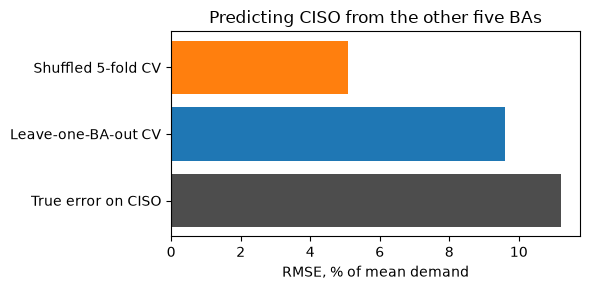

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(summary.index[::-1], summary.iloc[::-1, 0], color=["0.3", "tab:blue", "tab:orange"])
ax.set_xlabel("RMSE, % of mean demand")
ax.set_title(f"Predicting {test_ba} from the other five BAs")
plt.tight_layout()

Shuffled CV reports roughly half the error we actually get on the new
region: every test row has rows from the same BA, often from the
neighbouring hours, in its training folds, so the model never has to
generalise to a new grid. Leaving whole BAs out reproduces the real task
and lands close to the true error, at the price of a noisy estimate
(only five folds, and the folds differ a lot from one another).

### Every region as the deployed one

One held-out region is a single draw. Repeating the experiment with each
of the six BAs as the deployment target shows whether the pattern holds
(this cell fits 66 models and takes a few minutes).

In [6]:
rows = []
for ba in sorted(energy["ba"].unique()):
    is_test = energy["ba"] == ba
    X_tr, y_tr, groups = energy.loc[~is_test, features], y_rel[~is_test], energy.loc[~is_test, "ba"]
    X_te, y_te = energy.loc[is_test, features], y_rel[is_test]
    shuffled = -cross_val_score(model, X_tr, y_tr, cv=KFold(5, shuffle=True, random_state=0),
                                scoring="neg_root_mean_squared_error")
    by_ba = -cross_val_score(model, X_tr, y_tr, groups=groups, cv=LeaveOneGroupOut(),
                             scoring="neg_root_mean_squared_error")
    true_error = np.sqrt(np.mean((y_te - model.fit(X_tr, y_tr).predict(X_te)) ** 2))
    rows.append({"deployed BA": ba, "Shuffled 5-fold CV": shuffled.mean(),
                 "Leave-one-BA-out CV": by_ba.mean(), "True error": true_error})

by_region = (100 * pd.DataFrame(rows).set_index("deployed BA")).round(1)
by_region.loc["mean"] = by_region.mean().round(1)
by_region

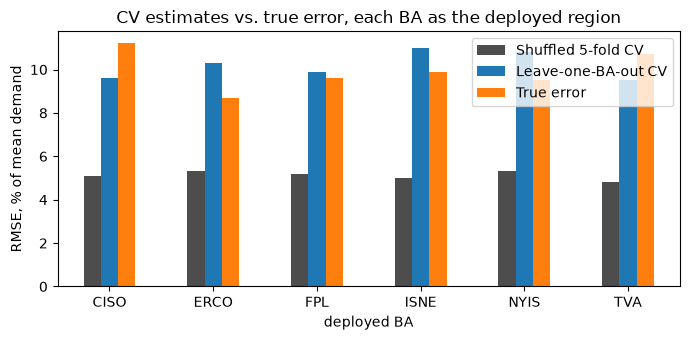

In [7]:
ax = by_region.drop("mean").plot.bar(figsize=(7, 3.5), color=["0.3", "tab:blue", "tab:orange"], rot=0)
ax.set_ylabel("RMSE, % of mean demand")
ax.set_title("CV estimates vs. true error, each BA as the deployed region")
plt.tight_layout()

Shuffled CV is about half the true error for every region, and it barely
changes with the region left out: it measures how well we interpolate
within grids we have seen. Leave-one-BA-out CV is close to the true
error on average, but for a single region it can be off by a point or
two in either direction.

## Takeaway

To grasp a little better the difference between the estimates, let us
think about what each is attempting to estimate.

The shuffled CV estimate is roughly estimating the final performance of
the following procedure: - take all consumption observations across all
regions and time, and put them all in a bag. - draw uniformly at random
a fration of the observations and fit a model to predict consumption on
it. - draw another distinct fraction of the data uniformly as random and
use the model to predict consumption on it.

The region aware split, on the other hand, estimates the final
performance of the following procedure: - take a subset of regions and
the observations of consumption on them across all time. - train a model
to predict consumption on them given a set of features. - take
observations from a new region and use the model to predict consumption
on it.

Even though the regions available to us on the full training may differ
from the region of final deployment, the within training data error
estimation procedure mimics the procedure we are actually carrying and
estimating the error of: we are training in a subset of regions to
predict into a new region. The more closely we can mimic the specific
details of this relation, the better our error estimates.

For example, if we had data from regions in both Mexico and the US, and
our final deployment would be in a new region in the US, our hold-out
set in the CV should also be a US and not a Mexico region, even thought
we could still train regions from Mexico, as those would be plausibly
present in the final training run.

# Summary

| Estimate | Unbiased for | As an estimate of the final model’s risk | Variance |
|------------------|------------------|------------------|------------------|
| Training error | not the risk (it measures the fit to the training labels) | too optimistic, worse for complex models |  |
| Validation error | risk of the model trained on $N_{\text{train}}$ points | too pessimistic; less so as $N_{\text{train}} \to N$ | grows as $N_{\text{valid}}$ shrinks |
| $K$-fold CV error | expected risk of a model trained on $N - N/K$ points | slightly pessimistic; less so as $K$ grows | not monotone in $K$ |

In the exercise you will see each row of this table in the practice
world, where you can compare every estimate with the true risk. Then you
will use CV to tune LightGBM on a challenge dataset with no true risk,
as in real life.